<a href="https://colab.research.google.com/github/nds-najam/Chronos_Model_Comparison/blob/main/notebooks/03_chronos2_multivariate_CLtrue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Chronos-2 Multivariate Analysis: Cross Learning True



#### Imports and environment

In [1]:
!pip install uv
!uv pip install -q "chronos-forecasting==2.3.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 59.5 MB/s eta 0:00:00


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline

print("Python environment ready")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Device: CPU")

Python environment ready
PyTorch version: 2.11.0+cpu
CUDA available: False
Device: CPU


In [3]:
# Clone Github Repository
REPO_DIR = Path("/content/Chronos_Model_Comparison")
if REPO_DIR.exists():
  print("Repository exists:", REPO_DIR.exists())
  %cd /content/Chronos_Model_Comparison
else:
  !git clone https://github.com/nds-najam/Chronos_Model_Comparison.git

Cloning into 'Chronos_Model_Comparison'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 136 (delta 77), reused 39 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 1.36 MiB | 9.45 MiB/s, done.
Resolving deltas: 100% (77/77), done.


In [4]:
# Load ETTh1
#
DATA_URL = (
    "https://raw.githubusercontent.com/zhouhaoyi/"
    "ETDataset/main/ETT-small/ETTh1.csv"
)

df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Shape: (17420, 8)
Columns:
['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [5]:
#
# Experiment Configuration
#
TARGET = "OT"

FEATURE_COLUMNS = [
    "HUFL",
    "HULL",
    "MUFL",
    "MULL",
    "LUFL",
    "LULL",
    "OT",
]

PREDICTION_LENGTH = 48

CONTEXT_LENGTHS = [
    512,
    1024,
    2048,
    4096,
    8192
]

CROSS_LEARNING = True

print("Target:", TARGET)
print("Variables:", FEATURE_COLUMNS)
print("Prediction length:", PREDICTION_LENGTH)
print("Context lengths:", CONTEXT_LENGTHS)
print("Cross learning:", CROSS_LEARNING)

Target: OT
Variables: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
Prediction length: 48
Context lengths: [512, 1024, 2048, 4096, 8192]
Cross learning: True


In [6]:
#
# Prepare train/test data
#
values = df[FEATURE_COLUMNS].values.astype(np.float32)

history_end = len(values) - PREDICTION_LENGTH

full_history = values[:history_end]
future = values[history_end:]

print("Full historical data:", full_history.shape)
print("Future/test data:", future.shape)

Full historical data: (17372, 7)
Future/test data: (48, 7)


In [7]:
#
# Actual OT
#
OT_INDEX = FEATURE_COLUMNS.index(TARGET)

actual_ot = future[:, OT_INDEX]

print("Actual OT shape:", actual_ot.shape)
print("Actual OT range:", actual_ot.min(), actual_ot.max())

Actual OT shape: (48,)
Actual OT range: 8.371 12.381


In [8]:
#
# Load Chronos-2
#
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading Chronos-2 on:", device)

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

print("Chronos-2 loaded successfully")

Loading Chronos-2 on: cpu


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded successfully


In [9]:
#
# MASE Function
#
def calculate_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    training_series: np.ndarray,
) -> float:
    """
    Calculate Mean Absolute Scaled Error using
    one-step naive forecast errors for scaling.
    """
    if len(training_series) < 2:
        raise ValueError("Training series must contain at least 2 observations.")

    naive_errors = np.abs(
        training_series[1:] - training_series[:-1]
    )

    scale = np.mean(naive_errors)

    if scale == 0:
        raise ValueError("MASE scaling factor is zero.")

    return float(
        np.mean(np.abs(actual - forecast)) / scale
    )

In [10]:
#
# Chronos-2 experiment function
#
def run_chronos2_experiment(
    context_length: int,
    cross_learning: bool = False,
) -> dict:
    """
    Run one Chronos-2 multivariate forecasting experiment.

    Parameters
    ----------
    context_length:
        Number of historical observations used by Chronos-2.

    cross_learning:
        Whether Chronos-2 cross-learning is enabled.

    Returns
    -------
    dict
        Forecast metrics and predictions.
    """

    if context_length > len(full_history):
        raise ValueError(
            f"context_length={context_length} exceeds "
            f"available history={len(full_history)}"
        )

    # Select the same final context window for every experiment.
    history = full_history[-context_length:]

    # Chronos-2 expects:
    # (n_series, n_variates, history_length)
    inputs = torch.tensor(
        history.T,
        dtype=torch.float32,
    ).unsqueeze(0)

    print(
        f"\nRunning C2 | "
        f"context={context_length} | "
        f"cross_learning={cross_learning}"
    )

    print("Input shape:", inputs.shape)

    start_time = time.perf_counter()

    quantiles, mean_forecast = pipeline.predict_quantiles(
        inputs,
        prediction_length=PREDICTION_LENGTH,
        context_length=context_length,
        cross_learning=cross_learning,
    )

    inference_time = time.perf_counter() - start_time

    # Extract OT forecast.
    forecast = (
        mean_forecast[0][OT_INDEX]
        .detach()
        .cpu()
        .numpy()
    )

    # Metrics.
    mae = mean_absolute_error(
        actual_ot,
        forecast,
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_ot,
            forecast,
        )
    )

    training_ot = history[:, OT_INDEX]

    mase = calculate_mase(
        actual_ot,
        forecast,
        training_ot,
    )

    print(f"MASE: {mase:.6f}")
    print(f"MAE : {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"Time: {inference_time:.3f} sec")

    return {
        "model": "Chronos-2",
        "mode": "multivariate",
        "context_length": context_length,
        "cross_learning": cross_learning,
        "prediction_length": PREDICTION_LENGTH,
        "MASE": mase,
        "MAE": mae,
        "RMSE": rmse,
        "inference_time_seconds": inference_time,
        "forecast": forecast,
        "actual": actual_ot.copy(),
        "history": history[:, OT_INDEX].copy(),
    }

In [25]:
results = []

for cl_value in [True, False]: # Iterate over True and False for cross_learning
    for context_length in CONTEXT_LENGTHS:
        result = run_chronos2_experiment(
            context_length=context_length,
            cross_learning=cl_value, # Use the iterated value
        )
        results.append(result)


Running C2 | context=512 | cross_learning=True
Input shape: torch.Size([1, 7, 512])
MASE: 2.176316
MAE : 0.845773
RMSE: 1.087534
Time: 1.899 sec

Running C2 | context=1024 | cross_learning=True
Input shape: torch.Size([1, 7, 1024])
MASE: 1.635091
MAE : 0.666521
RMSE: 0.886027
Time: 2.143 sec

Running C2 | context=2048 | cross_learning=True
Input shape: torch.Size([1, 7, 2048])
MASE: 2.260774
MAE : 0.997189
RMSE: 1.212150
Time: 3.600 sec

Running C2 | context=8192 | cross_learning=True
Input shape: torch.Size([1, 7, 8192])
MASE: 1.920440
MAE : 0.917299
RMSE: 1.149707
Time: 17.151 sec

Running C2 | context=512 | cross_learning=False
Input shape: torch.Size([1, 7, 512])
MASE: 2.176316
MAE : 0.845773
RMSE: 1.087534
Time: 1.092 sec

Running C2 | context=1024 | cross_learning=False
Input shape: torch.Size([1, 7, 1024])
MASE: 1.635091
MAE : 0.666521
RMSE: 0.886027
Time: 3.059 sec

Running C2 | context=2048 | cross_learning=False
Input shape: torch.Size([1, 7, 2048])
MASE: 2.260774
MAE : 0.99

In [26]:
leaderboard = pd.DataFrame([
    {
        "Model": r["model"],
        "Mode": r["mode"],
        "Context": r["context_length"],
        "Cross Learning": r["cross_learning"],
        "MASE": r["MASE"],
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "Inference Time (s)": r["inference_time_seconds"],
    }
    for r in results
])

leaderboard = leaderboard.sort_values(
    "MASE",
    ascending=True,
).reset_index(drop=True)

leaderboard

,Model,Mode,Context,Cross Learning,MASE,MAE,RMSE,Inference Time (s)
0,Chronos-2,multivariate,1024,True,1.635091,0.666521,0.886027,2.142991
1,Chronos-2,multivariate,1024,False,1.635091,0.666521,0.886027,3.059242
2,Chronos-2,multivariate,8192,False,1.920440,0.917299,1.149707,17.237520
3,Chronos-2,multivariate,8192,True,1.920440,0.917299,1.149707,17.151302
4,Chronos-2,multivariate,512,False,2.176316,0.845773,1.087534,1.091591
5,Chronos-2,multivariate,512,True,2.176316,0.845773,1.087534,1.898835
6,Chronos-2,multivariate,2048,True,2.260774,0.997189,1.212150,3.599647
7,Chronos-2,multivariate,2048,False,2.260774,0.997189,1.212150,3.822687


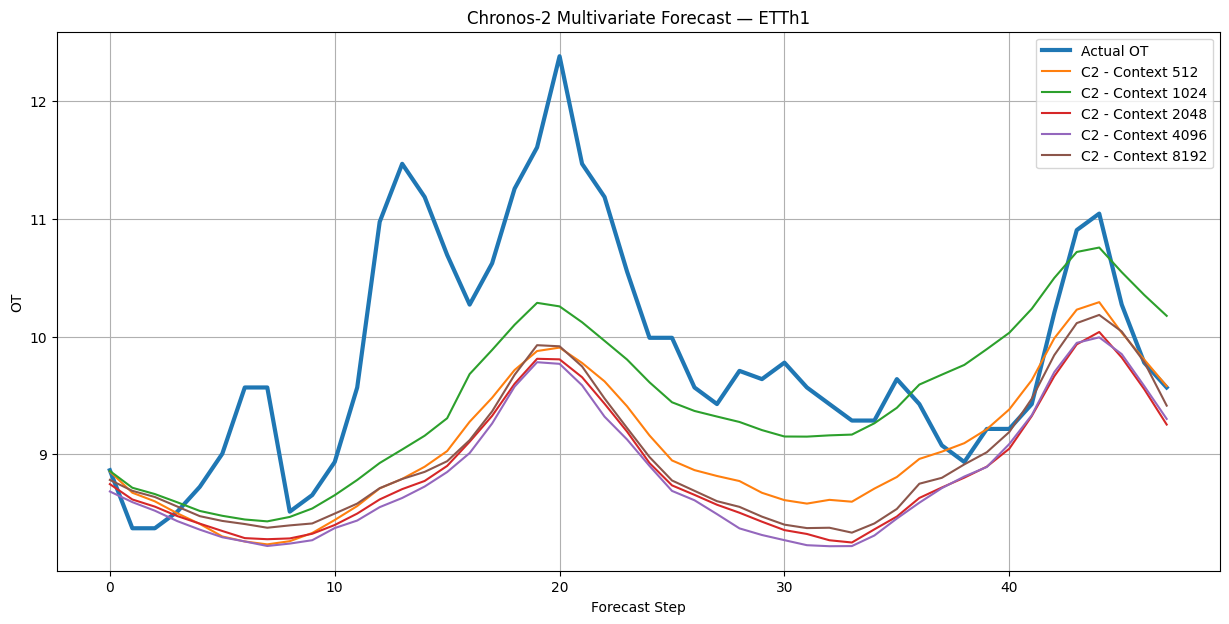

In [13]:
#
# Plot all three forecasts
#
plt.figure(figsize=(15, 7))

# Plot actual.
future_x = np.arange(PREDICTION_LENGTH)

plt.plot(
    future_x,
    actual_ot,
    label="Actual OT",
    linewidth=3,
)

# Plot each Chronos-2 forecast.
for result in results:

    plt.plot(
        future_x,
        result["forecast"],
        label=f"C2 - Context {result['context_length']}",
    )

plt.xlabel("Forecast Step")
plt.ylabel("OT")

plt.title(
    "Chronos-2 Multivariate Forecast — ETTh1"
)

plt.legend()
plt.grid(True)

plt.show()

In [14]:
#
# Plot history + forecast for the best model
#
best_result = min(
    results,
    key=lambda x: x["MASE"]
)

print(
    "Best context:",
    best_result["context_length"]
)

print(
    "Best MASE:",
    best_result["MASE"]
)

Best context: 1024
Best MASE: 1.6350913047790527


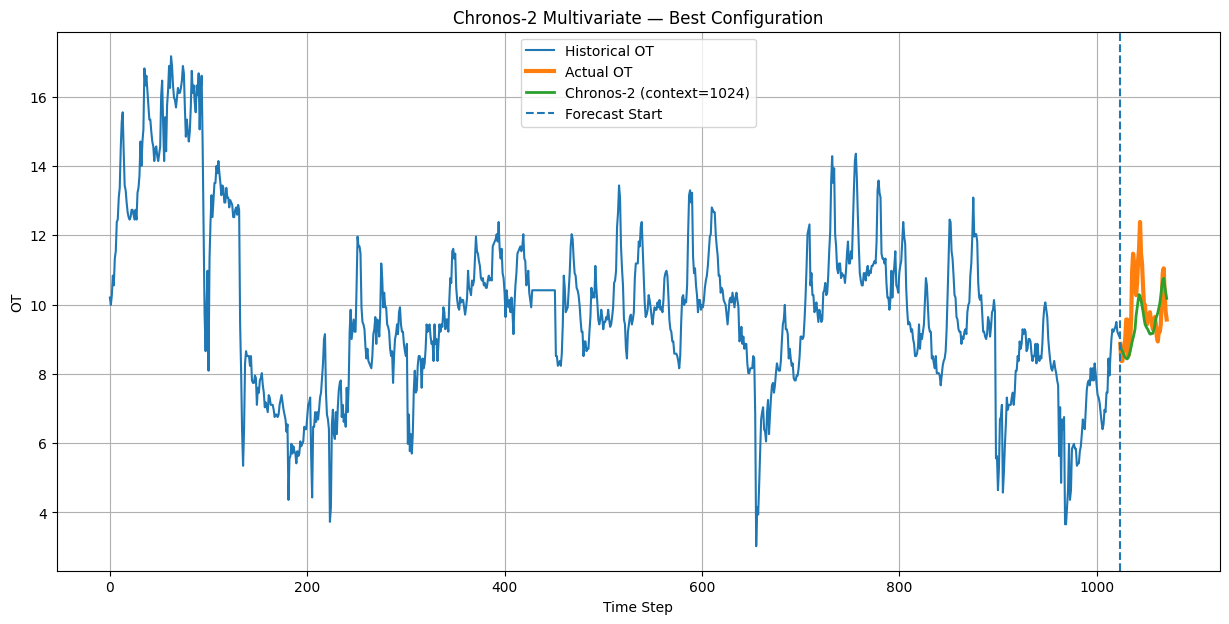

In [15]:
#
# Plot history + forecast for the best model
#
history_ot = best_result["history"]

history_x = np.arange(len(history_ot))

forecast_x = np.arange(
    len(history_ot),
    len(history_ot) + PREDICTION_LENGTH,
)

plt.figure(figsize=(15, 7))

plt.plot(
    history_x,
    history_ot,
    label="Historical OT",
)

plt.plot(
    forecast_x,
    actual_ot,
    label="Actual OT",
    linewidth=3,
)

plt.plot(
    forecast_x,
    best_result["forecast"],
    label=(
        f"Chronos-2 "
        f"(context={best_result['context_length']})"
    ),
    linewidth=2,
)

plt.axvline(
    len(history_ot),
    linestyle="--",
    label="Forecast Start",
)

plt.xlabel("Time Step")
plt.ylabel("OT")

plt.title(
    "Chronos-2 Multivariate — Best Configuration"
)

plt.legend()
plt.grid(True)

plt.show()

In [16]:
#
# Save Results
#
RESULTS_DIR = (
    REPO_DIR /
    "results" /
    "chronos2_multivariate"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(RESULTS_DIR)

/content/Chronos_Model_Comparison/results/chronos2_multivariate


In [17]:
#
# Leaderboard
#
leaderboard.to_csv(
    RESULTS_DIR / "leaderboard_c2m.csv",
    index=False,
)

print("Leaderboard saved.")

Leaderboard saved.


In [18]:
#
# Save Forecasts
#
for result in results:

    context = result["context_length"]

    np.save(
        RESULTS_DIR / f"c2m_forecast_context_{context}.npy",
        result["forecast"],
    )

np.save(
    RESULTS_DIR / "c2m_actual.npy",
    actual_ot,
)

In [19]:
#
# Save Metadata
#
metadata = {
    "dataset": "ETTh1",
    "target": TARGET,
    "variables": FEATURE_COLUMNS,
    "model": "Chronos-2",
    "mode": "multivariate",
    "prediction_length": PREDICTION_LENGTH,
    "context_lengths": CONTEXT_LENGTHS,
    "cross_learning": CROSS_LEARNING,
    "device": device,
    "torch_version": torch.__version__,
}

with open(
    RESULTS_DIR / "metadata.json",
    "w",
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
    )

print("Metadata saved.")

Metadata saved.


In [20]:
#
# Best Forecast
#
best_context = best_result["context_length"]

np.save(
    RESULTS_DIR / "c2m_best_forecast.npy",
    best_result["forecast"],
)

with open(
    RESULTS_DIR / "best_config.json",
    "w",
) as f:

    json.dump(
        {
            "context_length": best_context,
            "cross_learning": CROSS_LEARNING,
            "MASE": best_result["MASE"],
            "MAE": best_result["MAE"],
            "RMSE": best_result["RMSE"],
            "inference_time_seconds": (
                best_result["inference_time_seconds"]
            ),
        },
        f,
        indent=2,
    )

In [21]:
#
# Final Summary
#
print("=" * 70)
print("CHRONOS-2 MULTIVARIATE ETTh1 EXPERIMENT")
print("=" * 70)

print(f"Dataset             : ETTh1")
print(f"Target              : {TARGET}")
print(f"Variables           : {len(FEATURE_COLUMNS)}")
print(f"Prediction length   : {PREDICTION_LENGTH}")
print(f"Cross learning      : {CROSS_LEARNING}")
print(f"Device              : {device}")

print("\nLeaderboard:")
display(leaderboard)

print("\nBest configuration:")
print(f"Context length      : {best_context}")
print(f"MASE                : {best_result['MASE']:.6f}")
print(f"MAE                 : {best_result['MAE']:.6f}")
print(f"RMSE                : {best_result['RMSE']:.6f}")
print(
    "Inference time      : "
    f"{best_result['inference_time_seconds']:.3f} sec"
)

CHRONOS-2 MULTIVARIATE ETTh1 EXPERIMENT
Dataset             : ETTh1
Target              : OT
Variables           : 7
Prediction length   : 48
Cross learning      : True
Device              : cpu

Leaderboard:


,Model,Mode,Context,Cross Learning,MASE,MAE,RMSE,Inference Time (s)
0,Chronos-2,multivariate,1024,True,1.635091,0.666521,0.886027,4.593306
1,Chronos-2,multivariate,8192,True,1.920440,0.917299,1.149707,31.686188
2,Chronos-2,multivariate,512,True,2.176316,0.845773,1.087534,4.798212
3,Chronos-2,multivariate,2048,True,2.260774,0.997189,1.212150,8.145648
4,Chronos-2,multivariate,4096,True,2.329238,1.035098,1.256085,16.467476



Best configuration:
Context length      : 1024
MASE                : 1.635091
MAE                 : 0.666521
RMSE                : 0.886027
Inference time      : 4.593 sec
